# Analiza zmienności stanów wody na rzece Liwiec na stacji pomiarowej Zaliwie-Piegawki w latach 2016-2025

Autor: Małgorzata Matejko-Kurek  
Data: 03.2026

## Źródło danych

Dane wykorzystane w analizie pochodzą z bazy danych Instytutu Meteorologii i Gospodarki Wodnej - Państwowego Instytutu Badawczego (IMGW-PIB).

Dane obejmują dzienne pomiary stanu wody na rzece Liwiec ze stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025. Pomiary mają 10-minutową rozdzielczość czasową i pochodzą z Systemu Telemetrii (ST). Stan wody wyrażony jest w centymetrach.

## Cel analizy

Celem analizy jest zbadanie zmienności stanów wody na rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025.

Analiza obejmuje:
* zmienność stanów wody w czasie,
* różnice między latami,
* sezonowość zmian w ciągu roku.

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Wczytanie i przygotowanie danych

Dane zostały wczytane do środowiska Python i przygotowane do dalszej analizy z wykorzystaniem biblioteki pandas. Do wizualizacji wyników użyto biblioteki matplotlib.

In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Wczytanie wszystkich plików pomiarowych ze stacji hydrologicznych

dane = glob.glob("/Users/gosiamatejko/Desktop/Hydrologia/Pandas/B00020S_*.csv")

In [3]:
# Filtracja danych dla stacji Zaliwie-Piegawki

zaliwie_piegawki = []

for plik in dane:
    try:
        df = pd.read_csv(plik, sep=";", header=None, dtype={0:str, 3:str})
        df = df[df[0] == "152220010"]
        zaliwie_piegawki.append(df)
    except:
        print("Problem z plikiem",plik)

df = pd.concat(zaliwie_piegawki)
df.to_csv("liwiec.csv", index=False)



In [4]:
# Konwersja daty do formatu datetime w celu analizy czasowej

liwiec_pomiary = pd.read_csv("liwiec.csv", parse_dates=[2], date_format="%Y-%m-%d %H:%M", 
                         index_col=[2]).sort_index()
liwiec_pomiary = liwiec_pomiary.drop(columns=["0", "1", "4"])
liwiec_pomiary.index = liwiec_pomiary.index.normalize()
liwiec_pomiary.index.name = "Data Pomiaru"
liwiec_pomiary.columns = ["Stan Wody [cm]"]

## Wstępna eksploracja danych

In [5]:
liwiec_pomiary.head()

,Stan Wody [cm]
Data Pomiaru,
2016-01-01,126.0
2016-01-01,125.0
2016-01-01,126.0
2016-01-01,127.0
2016-01-01,127.0


In [6]:
liwiec_pomiary.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 518391 entries, 2016-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Stan Wody [cm]  518391 non-null  float64
dtypes: float64(1)
memory usage: 7.9 MB




Dane zostały poprawnie wczytane, obejmują okres 2016-2025 i zawierają dzienne pomiary stanu wody.

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Wizualizacja danych

## Zmiany stanów wody w czasie

Wykres przedstawia zmiany dziennych stanów wody na rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025.

In [7]:
# Obliczenie średnich wartości stanów wody w skali dziennej

srednia_dzienna = liwiec_pomiary.resample("D").mean()
srednia_dzienna = srednia_dzienna.rename(columns={"Stan Wody [cm]": "Średni Stan Wody [cm]"})
srednia_dzienna.index.name = "Data"

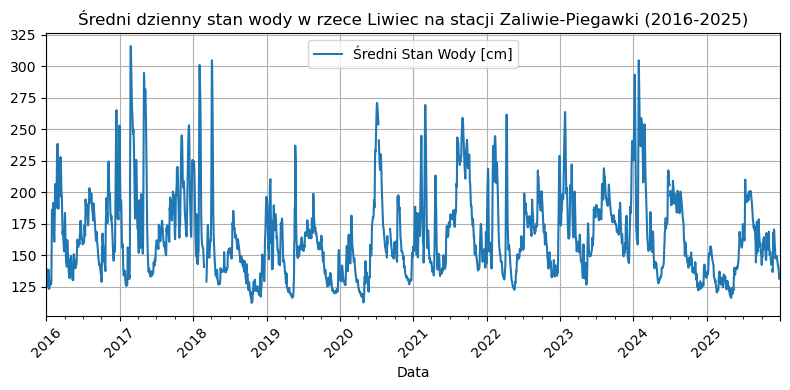

In [8]:
# Wizualizacja danych

srednia_dzienna.plot(figsize=(8,4))
plt.title("Średni dzienny stan wody w rzece Liwiec na stacji Zaliwie-Piegawki (2016-2025)") 
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Zmiany stanów wody w poszczególnych miesiącach

Wykres przedstawia zmiany średnich miesięcznych stanów wody w rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025.

In [9]:
# Obliczenie średnich miesięcznych stanów wody 

srednia_miesieczna = liwiec_pomiary.resample("ME").mean()
srednia_miesieczna = srednia_miesieczna.rename(columns={"Stan Wody [cm]": "Średni Stan Wody [cm]"})
srednia_miesieczna.index.name = "Data"
srednia_miesieczna.index = srednia_miesieczna.index.to_period("M")

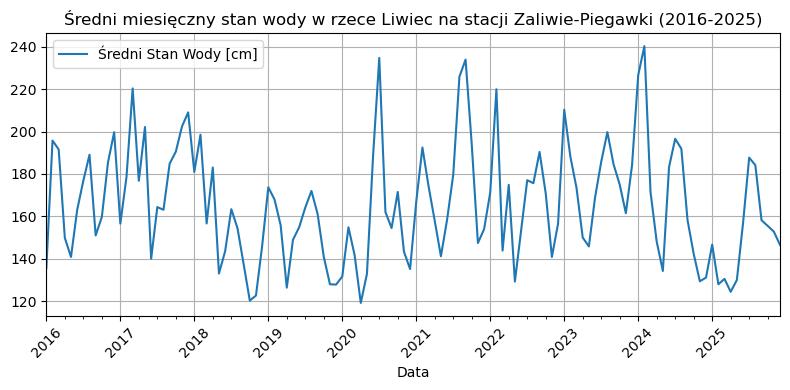

In [10]:
# Wizualizacja danych

srednia_miesieczna.plot(figsize=(8,4))
plt.grid(True)
plt.title("Średni miesięczny stan wody w rzece Liwiec na stacji Zaliwie-Piegawki (2016-2025)") 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Zmiany stanów wody w poszczególnych latach

Wykres przedstawia zmiany średniego rocznego stanu wody w rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025.

In [11]:
# Obliczenie średnich rocznych stanów wody

srednia_roczna = liwiec_pomiary.resample("YE").mean()
srednia_roczna = srednia_roczna.rename(columns={"Stan Wody [cm]": "Średni Stan Wody [cm]"})
srednia_roczna.index.name = "Rok"
srednia_roczna.index = srednia_roczna.index.year

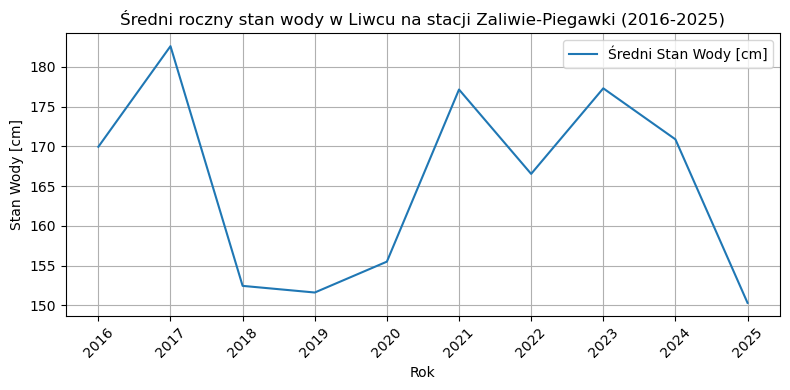

In [12]:
# Wizualizacja danych

srednia_roczna.plot(figsize=(8,4))
plt.grid(True)
plt.title("Średni roczny stan wody w Liwcu na stacji Zaliwie-Piegawki (2016-2025)")
plt.ylabel("Stan Wody [cm]")
plt.xticks(srednia_roczna.index, rotation=45)
plt.tight_layout()
plt.show()

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Sezonowość zmian stanów wody

Wykres przedstawia średni miesięczny stan wody w rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki, obliczony na postawie dziennych pomiarów z lat 2016-2025.

Pozwala on zobrazować sezonowe zmiany poziomu wody w ciągu roku oraz porównać średnie wartości stanów wody w poszczególnych miesiącach.

In [13]:
# Obliczenie średnich miesięcznych stanów wody z danych dla wszystkich lat

wszystkie_miesiace = pd.DataFrame(liwiec_pomiary.groupby(liwiec_pomiary.index.month)["Stan Wody [cm]"].mean())
wszystkie_miesiace.index = ["Styczen", "Luty", "Marzec", "Kwiecien", "Maj", "Czerwiec", "Lipiec", "Sierpien", "Wrzesien", "Pazdziernik", "Listopad", "Grudzien"]
wszystkie_miesiace.index.name = "Miesiac"
wszystkie_miesiace.columns = ["Sredni Stan Wody [cm]"]

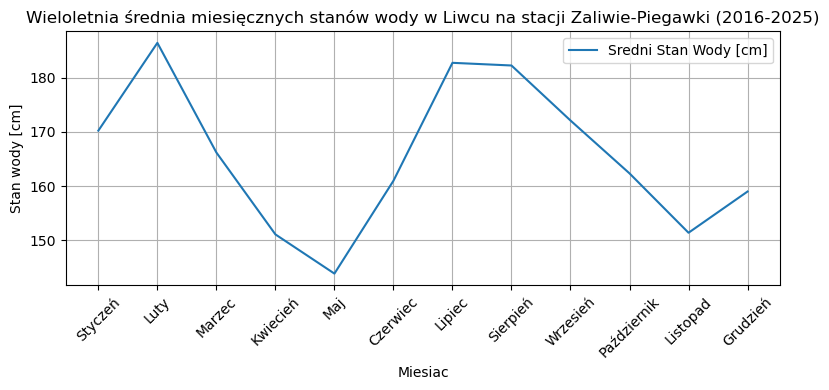

In [14]:
# Wizualizacja danych

wszystkie_miesiace.plot(figsize=(8,4))
plt.grid(True)
plt.title("Wieloletnia średnia miesięcznych stanów wody w Liwcu na stacji Zaliwie-Piegawki (2016-2025)")
plt.ylabel("Stan wody [cm]")
plt.xticks(range(0,12), ["Styczeń", "Luty", "Marzec", "Kwiecień", "Maj", "Czerwiec", "Lipiec", "Sierpień", "Wrzesień", "Październik", "Listopad", "Grudzień"], rotation=45)
plt.tight_layout()
plt.show()

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Wykres pudełkowy

Wykres pudełkowy przedstawia rozkład dziennych stanów wody w rzece Liwiec na stacji hydrologicznej Zaliwie-Piegawki w latach 2016-2025.

Pozwala on porównać zmienność poziomu wody między poszczególnymi latami oraz zidentyfikować wartości odstające, które mogą wskazywać na epizody wysokich stanów wody i wezbrań hydrologicznych.

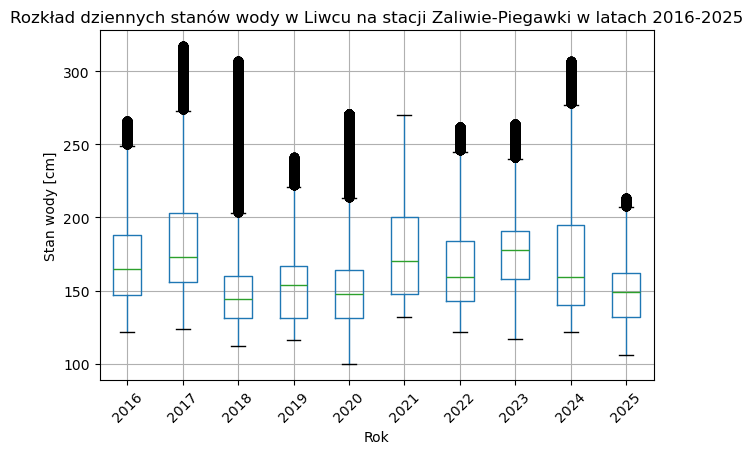

In [15]:
# Wizualizacja danych z wykorzystaniem wykresu boxplot

liwiec_pomiary = liwiec_pomiary.copy()
liwiec_pomiary["rok"] = liwiec_pomiary.index.year
liwiec_pomiary.boxplot(by="rok")
plt.suptitle("")
plt.title("Rozkład dziennych stanów wody w Liwcu na stacji Zaliwie-Piegawki w latach 2016-2025")
plt.ylabel("Stan wody [cm]")
plt.xlabel("Rok")
plt.xticks(rotation=45)
plt.tight_layout()

<div style="page-break-after: always; visibility: hidden; height: 0;"></div>

## Wnioski

Analiza danych hydrologicznych dla stacji Zaliwie-Piegawki na rzece Liwiec w latach 2016-2025 wykazuje na wyraźną zmienność poziomu wody zarówno w skali rocznej, jak i sezonowej.

Analiza średnich rocznych poziomów wody wskazuje, że poszczególne lata różnią się, a najwyższe średnie wartości odnotowano w latach 2017, 2021 oraz 2023, natomiast najniższe w latach 2025, 2018 oraz 2019. Niektóre epizody hydrologiczne mogą być maskowane przez agregację danych do poziomu średniej rocznej. 

Przykładem może być rok 2024, który nie wyróżnia się istotnie pod względem średnich rocznych wartości, jednak analiza miesięczna wskazuje na wyraźne wahania poziomu wody w ciągu roku. W 2024 odnotowano liczne przekroczenia stanów alarmowych, co wskazuje na wystąpienie intensywnych wezbrań hydrologicznych. Zdarzenia te są widoczne na wykresach miesięcznych i dziennych.

Analiza sezonowa wskazuje na występowanie wyższych stanów wody w okresie zimowym i wczesnowiosennym, co może być związane z roztopami oraz zwiększonym odpływem powierzchniowym. Widoczny jest również drugi wzrost poziomu wody w okresie letnim, który może być związany z intensywnymi opadami konwekcyjnymi i lokalnymi wezbraniami opadowymi.

Na wykresie pudełkowym widoczne są liczne wartości odstające, które wskazują na występowanie epizodów wysokich stanów wody w poszczególnych latach. Najwyższe wartości poziomu wody odnotowano w latach 2017, 2018 oraz 2024.

## Ograniczenia analizy

Analiza została przeprowadzona na podstawie danych z jednej stacji hydrologicznej (Zaliwie-Piegawki), co ogranicza możliwość wnioskowania o zmianach w całej zlewni rzeki Liwiec.

W analizie wykorzystano wyłącznie dane dotyczące stanów wody, bez uwzględnienia czynników meteorologicznych (np. opadów), które mogą mieć istotny wpływ na zmienność poziomu wody.

Ponadto agregacja danych do poziomu średnich miesięcznych i rocznych może maskować krótkotrwałe epizody hydrologiczne, takie jak wezbrania lub gwałtowne spadki poziomu wody.